# 02_04 - XGBoost Regressor: Training and Evaluation

The first real model of the project: a pooled, multi-output XGBoost regressor trained and evaluated on all 3 expanding-window folds, using the feature list and targets built in the previous notebooks.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from common.folds import iter_folds
from common.metrics import forecast_metrics, forecast_metrics_by_horizon
from forecast.XGBoost_Regressor import build_training_table, train_and_predict

DATA_PATH = Path.cwd().parents[1] / "data" / "interim" / "fsa_hourly_master.parquet"
df = pd.read_parquet(DATA_PATH)

table = build_training_table(df)
print("training table shape:", table.shape)

training table shape: (262800, 67)


## 1. Train and evaluate on all 3 folds

`build_training_table()` merges the 18 selected features (taken at each origin) with the 24-horizon targets, in both log scale (used to fit the model) and real kWh (used to score it). `train_and_predict()` fits one `XGBRegressor` per fold on the training years, predicts the test year, converts the log-scale predictions back to kWh with `expm1()`, and returns the results already in the required long-form schema.

This trains 3 separate multi-output models (one per fold) and takes a few minutes.

In [2]:
fold_results = {}
for fold_name, train_df, test_df in iter_folds(table):
    fold_results[fold_name] = train_and_predict(train_df, test_df)
    print(f"{fold_name} done - {len(fold_results[fold_name])} rows")

fold_1 done - 1261440 rows


fold_2 done - 1264896 rows


fold_3 done - 1257984 rows


## 2. Overall metrics per fold

In [3]:
summary = pd.DataFrame({
    fold_name: forecast_metrics(results["actual"], results["prediction"])
    for fold_name, results in fold_results.items()
}).T
summary

,mae,wape,rmse,mape,bias
fold_1,1096.411928,0.121477,1947.819988,10.135913,735.326483
fold_2,557.408276,0.060764,891.813461,5.969134,84.991379
fold_3,613.562168,0.063488,1032.389133,5.965348,314.609140


fold_1 comes out clearly worse than fold_2 and fold_3 on every metric (WAPE around 12% vs around 6%). That tracks with training set size - fold_1 only has 2 years of training data (2021-2022), while fold_2 and fold_3 have 3 and 4. More history to learn the seasonal pattern from gives a meaningfully better model, even with identical hyperparameters and no tuning. A WAPE around 6% for fold_2/fold_3 is a reasonable result for a first pass with default-ish settings and no tuning yet.

## 3. Error by horizon

Checking whether accuracy degrades as the forecast reaches further into the future - expected, since h+1 only needs to extrapolate one hour while h+24 needs to hold up a full day out.

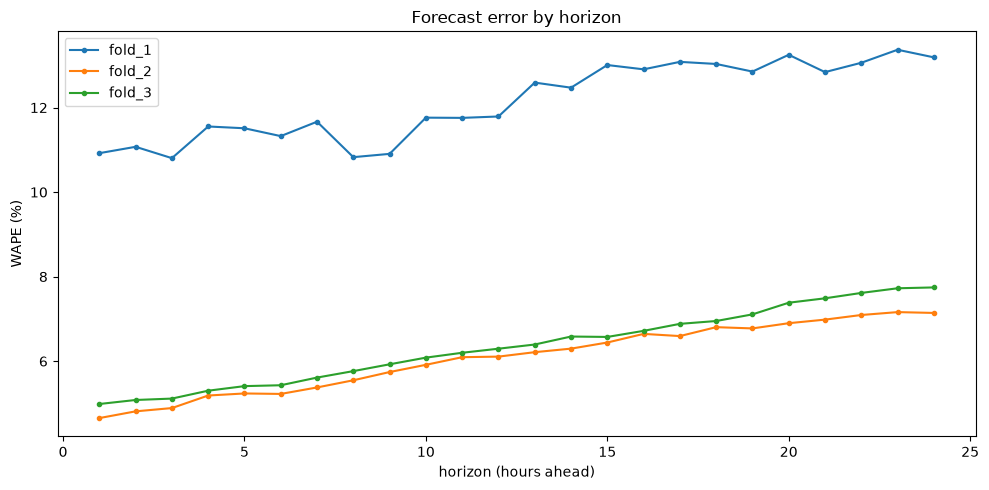

In [4]:
by_horizon = {fold_name: forecast_metrics_by_horizon(results) for fold_name, results in fold_results.items()}

fig, ax = plt.subplots(figsize=(10, 5))
for fold_name, metrics_df in by_horizon.items():
    ax.plot(metrics_df.index, metrics_df["wape"] * 100, marker="o", markersize=3, label=fold_name)
ax.set_xlabel("horizon (hours ahead)")
ax.set_ylabel("WAPE (%)")
ax.set_title("Forecast error by horizon")
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
pd.DataFrame({
    fold_name: {"wape_h1": metrics_df.loc[1, "wape"], "wape_h12": metrics_df.loc[12, "wape"], "wape_h24": metrics_df.loc[24, "wape"]}
    for fold_name, metrics_df in by_horizon.items()
}).T

,wape_h1,wape_h12,wape_h24
fold_1,0.109217,0.117898,0.131888
fold_2,0.046534,0.061078,0.071413
fold_3,0.049866,0.062951,0.077450


WAPE increases with horizon in all 3 folds, as expected: fold_2 goes from 4.65% at h+1 to 7.14% at h+24, fold_3 from 4.99% to 7.75% - both roughly a 55% relative increase over the 24-hour window. fold_1 goes from 10.92% to 13.19%, a smaller relative jump (about 21%) but starting from - and staying at - a much higher error throughout, consistent with it having the least training data of the three. The degradation is smooth and gradual rather than a cliff at any particular horizon, which is a reasonable shape for a first, untuned model.

## 4. Output schema check

Confirming the results already match the required output columns exactly: `FSA, origin_timestamp, forecast_timestamp, horizon, actual, prediction, model_name`.

In [6]:
fold_results["fold_3"].head()

,FSA,origin_timestamp,forecast_timestamp,horizon,actual,prediction,model_name
0,L4T,2025-01-01 00:00:00,2025-01-01 01:00:00,1,9428.1,9410.168945,xgboost_regressor
1,L4T,2025-01-01 01:00:00,2025-01-01 02:00:00,1,9076.3,8866.117188,xgboost_regressor
2,L4T,2025-01-01 02:00:00,2025-01-01 03:00:00,1,8616.3,8708.928711,xgboost_regressor
3,L4T,2025-01-01 03:00:00,2025-01-01 04:00:00,1,8331.8,8569.666992,xgboost_regressor
4,L4T,2025-01-01 04:00:00,2025-01-01 05:00:00,1,8252.4,8504.948242,xgboost_regressor
